# Now we will try our training regime with our newfound image data

In [16]:
%load_ext autoreload
%autoreload 2

import os
import torch
os.environ['TORCH'] = torch.__version__
print(torch.__version__)
# Choose device (cuda if available, else cpu)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Selected device:", device)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
2.9.0+cu128
Selected device: cuda


## Load Data

In [17]:
## Load the colmap data
import pycolmap
import pathlib
import utils.subset
import random
import utils.loaders

# Load the Colmap data into a torch dataset
model_path = pathlib.Path('./output/01_nerf/02_lego_large/1762043798762/0')
reconstruction = pycolmap.Reconstruction(model_path)

# Define the directory where our source images are from
image_dir = pathlib.Path('data', '01_nerf', '02_lego_large')

random.seed(42) # for reproducibility

# Sample images into disjoint sets
a_ids, b_ids = utils.subset.sample_image_subsets(reconstruction)

# Convert the reconstruction data into two sub-graphs
graph_a = utils.loaders.load_reconstruction_to_graph(reconstruction, image_dir, a_ids)
graph_b = utils.loaders.load_reconstruction_to_graph(reconstruction, image_dir, b_ids)

In [18]:
graph_b

Data(x=[33, 30], edge_index=[2, 940], image_tensors=[33], image_paths=[33], image_files=[33])

## Create training data

In [19]:
# Example of creating a dataset via perturbations on one pair of graph subset
torch.manual_seed(42)
random.seed(42)
# We will create 300 examples
perturbs = torch.empty(300, 3).uniform_(-10.0, 10.0)
# Clone subgraph_b and perturb it for each data point
graph_a_list = []
graph_b_list = []
for perturbation in perturbs:
    new_graph = graph_b.clone()
    # Add the perturbation to the translation node features (columns 0, 1, 2 of the feature matrix x)
    new_graph.x[:,:3] = new_graph.x[:,:3] + perturbation
    # new_graph.x = new_graph.x + perturbation
    # Each example is [graph_a, graph_b, perturbation], where perturbation is our label
    graph_a_list.append(graph_a.clone()) # TODO should we clone this? I'll do it just to avoid any unforeseen bugs...
    graph_b_list.append(new_graph)

# Just to make it clearer what we are talking about
labels = perturbs

In [20]:
from utils.loaders import GraphPairDataset

# Create the Dataset!
dataset = GraphPairDataset(graph_a_list, graph_b_list, labels)

# Training Loop

In [21]:
from torch_geometric.loader import DataLoader
from torch.utils.data import random_split

# Split our dataset based on 80-20 training-validation split
dataset_size = len(dataset)
train_size = int(dataset_size * 0.8)
val_size = dataset_size - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# And we create s distinct DataLoader for each dataset train and val
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

In [22]:
import numpy as np
from models import SiameseGCN_v1
from tqdm import tqdm

torch.manual_seed(43)
random.seed(43)

# Define model
model = SiameseGCN_v1(graph_a.num_features)
model.to(device)

optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
# optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.8)
criterion = torch.nn.MSELoss()

num_epochs = 400

# Keep track of loss
epoch_losses_train = []
epoch_losses_val = np.full(num_epochs, np.nan)  # one slot per epoch
with tqdm(range(num_epochs),desc=f"Training progress") as pbar:
    for epoch in pbar:
        model.train()
        train_loss = 0.0
        for batch in train_loader:
            # Move data to the GPU
            graph_a_batch = batch[0].to(device)
            graph_b_batch = batch[1].to(device)
            label_batch   = batch[2].to(device)
            optimizer.zero_grad()
            out = model(graph_a_batch, graph_b_batch)
            loss = criterion(out, label_batch)
            # Compute gradient
            loss.backward()
            # update the weights
            optimizer.step()
            train_loss += loss.item()
        avg_loss = train_loss / len(train_loader)
        epoch_losses_train.append(avg_loss)
        pbar.set_postfix({'loss': f'{avg_loss:.4f}' })
        # learning rate decay
        scheduler.step()

        # Validation
        if epoch % 10 == 0:
            model.eval()
            val_loss = 0.0
            with torch.no_grad():
                for batch in val_loader:
                    graph_a_batch = batch[0].to(device)
                    graph_b_batch = batch[1].to(device)
                    label_batch   = batch[2].to(device)
                    out = model(graph_a_batch, graph_b_batch)
                    loss = criterion(out, label_batch)
                    val_loss += loss.item()
            epoch_losses_val[epoch] = val_loss / len(val_loader)

Training progress: 100%|██████████| 400/400 [01:27<00:00,  4.55it/s, loss=0.0002] 


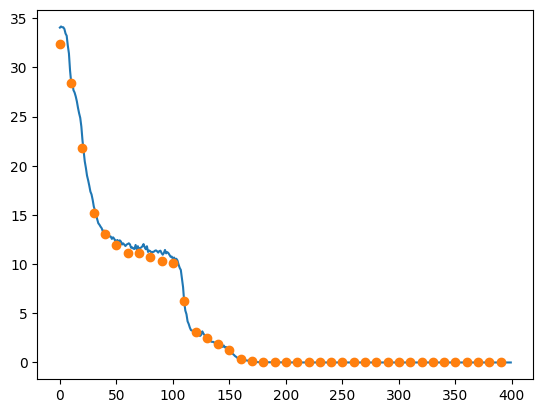

In [23]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(epoch_losses_train)
plt.plot(epoch_losses_val, marker='o')
plt.show()

## Results

Great! Seems like it is even performing better than the original without any image data??

# Take 2: More complex model

Let's try building up a more complex model.

In [24]:
import torch
from torch import nn
from torch_geometric.nn import GCNConv, global_mean_pool
import torch.nn.functional as F
import torch_geometric.data

class GraphEmbeddingGCN_v2(nn.Module):
    def __init__(self, num_node_features: int, output_dim: int):
        super().__init__()
        self.conv1 = GCNConv(num_node_features, 64)
        self.conv2 = GCNConv(64, 64)
        self.linear = nn.Linear(64, output_dim)

    def forward(self, graph_data: torch_geometric.data.Data):
        h = self.conv1(graph_data.x, graph_data.edge_index)
        h = F.relu(h)
        h = self.conv2(h, graph_data.edge_index)
        h = F.relu(h)
        # Pool all the node features to get a graph-level representation
        h = global_mean_pool(h, graph_data.batch)
        h = self.linear(h)
        return h

# This is a super simple network that takes a graph as input, and outputs a single scalar
class SiameseGCN_v2(nn.Module):
    def __init__(self, num_node_features: int):
        super().__init__()
        # Create twin branches that process each graph in tandem
        graph_embedding_dim = 16
        self.sisterA = GraphEmbeddingGCN_v2(num_node_features, output_dim = graph_embedding_dim)
        self.sisterB = GraphEmbeddingGCN_v2(num_node_features, output_dim = graph_embedding_dim)

        # This next part will take as input the embeddings from the sister network
        # self.conv1 = GCNConv(graph_embedding_dim * 2, 4)
        self.linear1 = nn.Linear(graph_embedding_dim * 2, 8)
        self.linear2 = nn.Linear(graph_embedding_dim * 2, 8)
        self.mlp = nn.Sequential(
            nn.Linear(graph_embedding_dim * 2, 8),
            nn.ReLU(),
            nn.Linear(8, 8),
            nn.ReLU(),
            # Output 3 scalars for (x, y, z) translation prediction
            nn.Linear(8, 3)
        )

    def forward(self, graph_data_1: torch_geometric.data.Data, graph_data_2: torch_geometric.data.Data):
        # Project graph1 and graph2 into the "embedding space" (idk if this is properly called an embedding space...)
        e1 = self.sisterA(graph_data_1)
        e2 = self.sisterB(graph_data_2)

        # Concatenate the features
        h = torch.cat((e1, e2), dim=1)
        # Run through an MLP to predict 3
        h = self.mlp(h)
        return h

In [ ]:
import numpy as np
from models import SiameseGCN_v1
from tqdm import tqdm

# Define model
model = SiameseGCN_v1(graph_a.num_features)
model.to(device)

optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
# optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.8)
criterion = torch.nn.MSELoss()

num_epochs = 400

# Keep track of loss
epoch_losses_train = []
epoch_losses_val = np.full(num_epochs, np.nan)  # one slot per epoch
with tqdm(range(num_epochs),desc=f"Training progress") as pbar:
    for epoch in pbar:
        model.train()
        train_loss = 0.0
        for batch in train_loader:
            # Move data to the GPU
            graph_a_batch = batch[0].to(device)
            graph_b_batch = batch[1].to(device)
            label_batch   = batch[2].to(device)
            optimizer.zero_grad()
            out = model(graph_a_batch, graph_b_batch)
            loss = criterion(out, label_batch)
            # Compute gradient
            loss.backward()
            # update the weights
            optimizer.step()
            train_loss += loss.item()
        avg_loss = train_loss / len(train_loader)
        epoch_losses_train.append(avg_loss)
        pbar.set_postfix({'loss': f'{avg_loss:.4f}' })
        # learning rate decay
        scheduler.step()

        # Validation
        if epoch % 10 == 0:
            model.eval()
            val_loss = 0.0
            with torch.no_grad():
                for batch in val_loader:
                    graph_a_batch = batch[0].to(device)
                    graph_b_batch = batch[1].to(device)
                    label_batch   = batch[2].to(device)
                    out = model(graph_a_batch, graph_b_batch)
                    loss = criterion(out, label_batch)
                    val_loss += loss.item()
            epoch_losses_val[epoch] = val_loss / len(val_loader)

Training progress:  40%|███▉      | 158/400 [00:33<00:48,  4.97it/s, loss=12.5217]

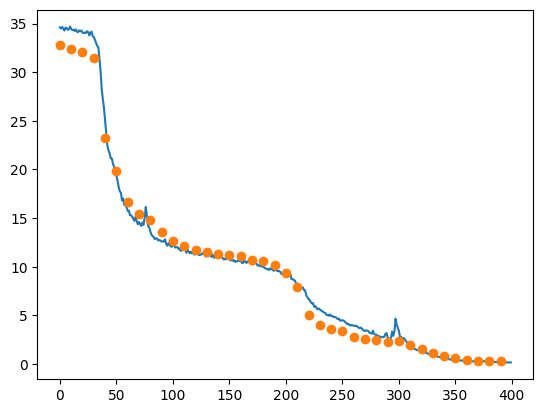

In [15]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(epoch_losses_train)
plt.plot(epoch_losses_val, marker='o')
plt.show()